# Homework Assignment 4
## Regression and Classification models

### <p style="text-align: right;"> &#9989; Jaehan Kim</p>
### <p style="text-align: right;"> &#9989; Jaehan-MSU</p>

### Goal for this homework assignment
By now, you have learned a bit about regression models. In this assignment, you will practice:

* Using branches in Git
* Performing multiple linear regression
* Performing classification with logistic regression, perceptrons, and SVMs
* Using PCA for dimensionality reduction

**This assignment is due by 11:59 pm on Friday, July 31st.** It should be uploaded into the "Homework Assignments" submission folder for Homework 4.  Submission instructions can be found at the end of the notebook. **There are 70 standard points possible in this assignment. The distribution of points can be found in the section headers**.


---
## Part 1: Git Branch (6 points)

<img src="https://thumb.ac-illust.com/5d/5d177cfa2b1d4adf086d924032723df4_t.jpeg" alt='https://en.ac-illust.com/clip-art/22520113/school-anthropometry' width=250px align="right" style="margin-left: 15px">

For this assignment, you're going to add it to the `cmse202-s26-turnin` repository you created in class so that you can track your progress on the assignment and preserve the final version that you turn in. In order to do this you need to

**&#9989; Do the following**:

1. Navigate to your `cmse202-s26-turnin` **local** repository and create a new directory called `hw-04`

2. Move this notebook into that **new directory** in your repository, but **do not** add or commit it to your repository yet.

3. Create a **new branch** called `hw04_branch` 

4. "Check out" the new branch (so that you'll be working on that branch). 

5. Double check to make sure you are actually on that branch.

6. Once you're certain you're working on your new branch, add this notebook to your repository, then make a commit and push it to GitHub. You may need to use `git push origin hw04_branch` to push your new branch to GitHub.

Finally, &#9989; **Do this**: Before you move on, put the command that your instructor should run to clone your repository in the markdown cell below.

<font size=6 color="#009600">&#9998;</font> git clone https://github.com/Jaehan-MSU/cmse202-s26-turnin.git

**Important**: Double check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the previous homework assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-s26-turnin`" repository inside the `hw-04` directory that you just created within the new branch `hw04-branch`.

Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the project for a bit.


---
## Part 2: Loading and Summarizing an Anthropometric Dataset (9 points)
 <img src="https://www.egr.msu.edu/~aalessio/imgs/the-proportions-of-the-human-figure-leonardo-da-vinci.png"
     alt="da vinci human"
     align="right"  
     width="200" />  

<a href="https://en.wikipedia.org/wiki/Anthropometry">**Anthropometry**</a> is the scientific study of the measurements and proportions of the human body.  This field has a critical role in several industries including clothing design, ergonomics, healthcare, consumer safety, and architecture. 

For the majority of this homework, you'll be working with the The "anthrokids_subset.csv" file that contains 5 columns with the following contents: 

**[Age (years), Weight (kg), Height (cm), Head Circumference (cm), Waist Circumference (cm)].**  

These data are a subset of the data acquired in the 
<a href="http://mreed.umtri.umich.edu/mreed/downloads.html#child_anthro">Synder et al, 1975: ANTHROPOMETRY OF INFANTS,CHILDREN, AND YOUTHS TO AGE 18 FOR PRODUCT SAFETY DESIGN,</a> performed by the U.S. Consumer Product Safety Commission to design some of the original car seats for children. 

The dataset is available here:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/anthrokids3_subset.csv`

&#9989; **Question 2.1 (1 points)**: To get started, **download the `anthrokids3_subset.csv` file and place it in the same directory as your notebook**.

``` bash
# Put the command you used to download the file here.
curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/anthrokids3_subset.csv
```

&#9989;  **Question 2.2 (2 points)**: Next, load the data into a Pandas DataFrame and display the first and last 5 rows. 

In [46]:
# Put your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

anthro_raw = pd.read_csv("anthrokids3_subset.csv")
anthro_raw = anthro_raw.iloc[:, :5].copy()
anthro_raw.columns = [
    "age_years",
    "weight_kg",
    "height_cm",
    "head_circumference_cm",
    "waist_circumference_cm"
]

display(anthro_raw.head())
display(anthro_raw.tail())

,age_years,weight_kg,height_cm,head_circumference_cm,waist_circumference_cm
0,4.219,15.5,103.3,47.5,49.8
1,4.326,17.6,103.9,49.8,50.6
2,4.476,23.0,111.2,52.0,51.2
3,3.841,16.5,99.7,49.1,48.9
4,3.460,15.0,99.7,46.5,47.3


,age_years,weight_kg,height_cm,head_circumference_cm,waist_circumference_cm
1772,4.704,20.1,108.6,57.4,52.8
1773,4.131,17.8,100.8,50.6,49.7
1774,5.120,21.7,114.9,53.1,51.2
1775,5.342,20.7,112.1,52.9,51.9
1776,5.495,18.1,110.8,46.8,48.9


&#9989;  **Question 2.3 (2 points)**: First, convert all of these variables from metric to imperial units (i.e. weight from kg to pounds, height from cm to feet, and head circumference and waist circumference from cm to inches). Display the mean and standard deviation of each variable after converting to imperial units.  If you created new columns for the imperial units, we suggest that you remove the old columns that have the metric units.




In [47]:
# Put your code here
anthro = pd.DataFrame()
anthro["age_years"] = anthro_raw["age_years"]
anthro["weight_lbs"] = anthro_raw["weight_kg"] * 2.20462
anthro["height_ft"] = anthro_raw["height_cm"] * 0.0328084
anthro["head_circumference_in"] = anthro_raw["head_circumference_cm"] * 0.393701
anthro["waist_circumference_in"] = anthro_raw["waist_circumference_cm"] * 0.393701
display(anthro.head())

summary_stats = anthro.describe().loc[["mean", "std"]]
display(summary_stats)

,age_years,weight_lbs,height_ft,head_circumference_in,waist_circumference_in
0,4.219,34.171610,3.389108,18.700798,19.606310
1,4.326,38.801312,3.408793,19.606310,19.921271
2,4.476,50.706260,3.648294,20.472452,20.157491
3,3.841,36.376230,3.270997,19.330719,19.251979
4,3.460,33.069300,3.270997,18.307097,18.622057


,age_years,weight_lbs,height_ft,head_circumference_in,waist_circumference_in
mean,10.579407,82.975967,4.583215,24.421559,20.804893
std,4.201508,38.358233,0.785338,4.289691,1.013658


&#9989;  **Question 2.4 (4 points)**: For additional exploration of this data, make three scatter plots (side-by-side) that display the relationship between weight and age, and then height and age, and then waist circumference and age. You can use any plotting library you like for this task.  This should display weight (the dependent variable) as a function of age (the independent variable on the x-axis) and height (the dependent variable) as a function of age (the independent variable) and waist circumference (the dependent variable) as a function of age (the independent variable).  Label all of your axes.






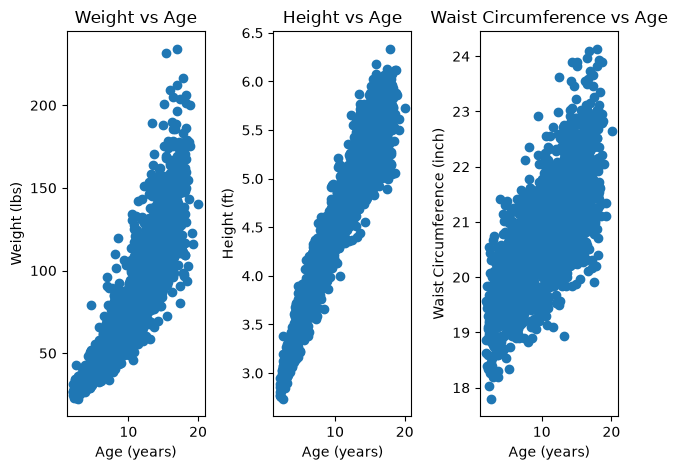

In [48]:
# Put your code here
fig, axes = plt.subplots(1, 3)

axes[0].scatter(anthro["age_years"], anthro["weight_lbs"])
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Weight (lbs)")
axes[0].set_title("Weight vs Age")

axes[1].scatter(anthro["age_years"], anthro["height_ft"])
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Height (ft)")
axes[1].set_title("Height vs Age")

axes[2].scatter(anthro["age_years"], anthro["waist_circumference_in"])
axes[2].set_xlabel("Age (years)")
axes[2].set_ylabel("Waist Circumference (inch)")
axes[2].set_title("Waist Circumference vs Age")

plt.tight_layout()
plt.show()

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 2 complete", and push the changes to GitHub.



---
 <img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/refs/heads/main/images/helmet-logo-image.png"
     alt="perplexity pro,https://www.perplexity.ai,''Make a logo for a fictional company called Helmets 'R Us, Inc'', 4/1/2026"
     width="500"/>  

## Part 3: Multivariable Linear Regression (9 points)


For this homework, let's assume that we work for a company that makes helmets for children (Helmet's R Us, Inc.).  We want to be able to predict good helmet sizes for children based on their age, weight, height, and waist circumference.  We have the data from the Synder et al. study to help us with this task.

In this part, we will try to estimate head circumference (which is a critical measurement for helmet size) using the other measurements in the dataset.  

&#9989;  **Question 3.1 (3 points)**: Using the `OLS` method in `statsmodels`, perform a linear regression to predict head circumference from the other variables and **display the results summary**. Make sure `OLS` fits a general line $y = ax+b$ to the data instead of a line through the origin $y = ax$. 

The input variables that you have access to are age, weight, height, and waist circumference. 



In [49]:
# Put your code here
import statsmodels.api as sm

X = anthro[[
    "age_years",
    "weight_lbs",
    "height_ft",
    "waist_circumference_in"
]]
y = anthro["head_circumference_in"]

X_const = sm.add_constant(X)

head_model = sm.OLS(y, X_const).fit()
print(head_model.summary())

                              OLS Regression Results                             
Dep. Variable:     head_circumference_in   R-squared:                       0.880
Model:                               OLS   Adj. R-squared:                  0.880
Method:                    Least Squares   F-statistic:                     3245.
Date:                   Fri, 31 Jul 2026   Prob (F-statistic):               0.00
Time:                           22:51:34   Log-Likelihood:                -3225.6
No. Observations:                   1777   AIC:                             6461.
Df Residuals:                       1772   BIC:                             6489.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

&#9989;  **Question 3.2 (4 points)**: Answer the following questions: 

1. What was the equation of the best fit linear relationship between the input variables and the target variable, head circumference? (2 pts)

2. Which input variable is least useful for detecting the target variable? What tells you this? (1 pts)

3. As age increases, how does the head circumference change? Describe a reason why this behavior occurs?  (1 pts)


<font size=+3>&#9998;</font> Put your 3 answers here:
1. Best fit linear equation is
head_circumference_in = intercept + coefficient_age * age_years + coefficient_weight * weight_lbs + coefficient_height * height_ft + coefficient_waist * waist_circumference_in, which is 18.2659 - 0.0612(age_years) + 0.1266(weight_lbs) - 0.8760(height_ft) + 0.0150(waist_circumference_in),
using coefficeints from OLS regression summary

2. Least useful input variable I think is waist_circumference_in. This is because it has largest p-value, 0.806. Since this p-value is much larger than 0.05, waist circumference is not statistically significant in this model.

3. As age increases, head circumference slightly decreases in this model because age coefficient is -0.0612. It is pretty surprising, but the model is also controlling for weight, height, and waist circumference. Since these body measurements are related to age, negative age coefficient may happen because of overlap between variables.

&#9989;  **Question 3.3 (2 points)**: Based on this model, what is the head circumference of a child who is 5 years old, weighs 40 pounds, is 3.7 feet tall, and has a waist circumference of 21 inches? Show your work.

In [50]:
# Put your code here or your manual calculations here 
new_child = pd.DataFrame({
    "const": [1],
    "age_years": [5],
    "weight_lbs": [40],
    "height_ft": [3.7],
    "waist_circumference_in": [21]
})

print("Predicted head circumference:", head_model.predict(new_child)[0], "inches")

Predicted head circumference: 20.09881069221467 inches


The predicted head circumference is printed above in inches.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 3 complete", and push the changes to GitHub.

---

## Part 4: Logistic Regression (18 points)

Helmet's R Us, Inc. has made the decision to only make two sizes of helmets: Small (for infants) and Large (for older children). 

We will use classification techniques to determine which children should get the small helmets and which should get the large helmets. We will assume that parents and guardians will only have access to a child's age, weight, height when they are trying to decide which helmet size to buy.

&#9989;  **Question 4.1 (2 points)**: Binarize the head circumference variable to create a new dataframe column called `helmet_size` that has two values: "Small" for head circumferences less than 20.5 inches and "Large" for head circumferences greater than or equal to 20.5 inches. Display the first 10 rows of the new `helmet_size` column and the first 10 rows of the original `head_circumference` column to verify that you created the new variable correctly.

In [51]:
# Put your code here
anthro["helmet_size"] = np.where(
    anthro["head_circumference_in"] < 20.5,
    "Small",
    "Large"
)
display(anthro[["head_circumference_in", "helmet_size"]].head(10))

,head_circumference_in,helmet_size
0,18.700798,Small
1,19.606310,Small
2,20.472452,Small
3,19.330719,Small
4,18.307097,Small
5,19.803160,Small
6,18.070876,Small
7,18.149616,Small
8,19.960641,Small
9,21.063004,Large


We want to prepare our data for the following classification models, with the understanding that you will be trying to predict the `helmet_size` variable using only the age, weight (in lbs), and height (in feet) variables.

&#9989;  **Question 4.2 (2 points)**: Create a new dataframe variable that has just the age, weight, and height variables (inputs) as the features and the `helmet_size` variable as the labels (output). Display the first 5 rows of the features and labels to verify that you created these variables correctly.

In [52]:
# put your code here
features = anthro[["age_years", "weight_lbs", "height_ft"]]
labels = anthro["helmet_size"]

display(features.head())
display(labels.head())

,age_years,weight_lbs,height_ft
0,4.219,34.171610,3.389108
1,4.326,38.801312,3.408793
2,4.476,50.706260,3.648294
3,3.841,36.376230,3.270997
4,3.460,33.069300,3.270997


0    Small
1    Small
2    Small
3    Small
4    Small
Name: helmet_size, dtype: object

&#9989;  **Question 4.3 (3 points)**: To gain some intuition of the relationship between the features and the labels, make three boxplots that display the distribution of age, weight, and height for each helmet size. You can use any plotting library you like for this task.  This should display the distribution of age, weight, and height for each helmet size. (boxplots of age on the y-axis and helmet size on the x-axis, boxplots of weight on the y-axis and helmet size on the x-axis, and boxplots of height on the y-axis and helmet size on the x-axis).  Label all of your axes.

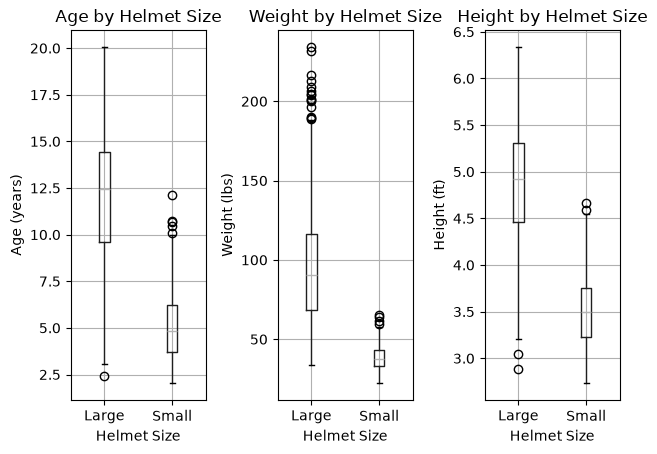

In [53]:
# Put your code here
fig, axes = plt.subplots(1, 3)

anthro.boxplot(column="age_years", by="helmet_size", ax=axes[0])
axes[0].set_xlabel("Helmet Size")
axes[0].set_ylabel("Age (years)")
axes[0].set_title("Age by Helmet Size")

anthro.boxplot(column="weight_lbs", by="helmet_size", ax=axes[1])
axes[1].set_xlabel("Helmet Size")
axes[1].set_ylabel("Weight (lbs)")
axes[1].set_title("Weight by Helmet Size")

anthro.boxplot(column="height_ft", by="helmet_size", ax=axes[2])
axes[2].set_xlabel("Helmet Size")
axes[2].set_ylabel("Height (ft)")
axes[2].set_title("Height by Helmet Size")

plt.suptitle("")
plt.tight_layout()
plt.show()

&#9989;  **Question 4.4 (1 points)**: Now that you've visualized the data some, Do you think this data is linearly separable? Why or why not?

<font size=+3>&#9998;</font> 
Data looks mostly separable, but probably not perfectly linearly separable. Older, heavier, and taller children are more likely to need Large helmets, but I think there is still some overlap between the small and large groups.

&#9989;  **Question 4.5 (2 points)**: Finally, before we start creating our models, let's first split our data into training and testing datasets. Make the training set have 75\% of the data and the testing set have 25\% of the data. Set the random seed to 42 so that your results are reproducible. 

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
# Put your code here
X_train, X_test, y_train_label, y_test_label = train_test_split(
    features,
    labels,
    test_size=0.25,
    random_state=42
)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train_label.shape)
print("Testing labels shape:", y_test_label.shape)

Training features shape: (1332, 3)
Testing features shape: (445, 3)
Training labels shape: (1332,)
Testing labels shape: (445,)


&#9989;  **Question 4.6 (3 points)**: Now, train a logistic regression model to predict helmet size from age, weight, and height. Perform the training on the training set.  Display a summary of the model (to show the coefficients for each feature).  You can use methods from `statsmodels` or `sklearn` to perform logistic regression. 

In [56]:
from sklearn.metrics import accuracy_score

In [57]:
# Put your code here
y_train = (y_train_label == "Large").astype(int)
y_test = (y_test_label == "Large").astype(int)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.127011
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:            helmet_size   No. Observations:                 1332
Model:                          Logit   Df Residuals:                     1328
Method:                           MLE   Df Model:                            3
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.7511
Time:                        22:51:34   Log-Likelihood:                -169.18
converged:                       True   LL-Null:                       -679.63
Covariance Type:            nonrobust   LLR p-value:                5.254e-221
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.8794      3.352     -1.754      0.079     -12.449       0.690
age_years     -0.1183      0

&#9989;  **Question 4.7 (2 points)**: Evaluate the performance on the training and testing set.  Display the accuracy of the logistic regression model when applied to both the training and testing sets.

**Note:** Accuracy should be better than 75% on the test set.  If you are not getting better than 75% accuracy on the test set, try to troubleshoot your code and see if you can find any errors. If you can't find any errors, then just report the accuracy that you got and move on to the next question.

In [58]:
# Put your code here
train_probs = logit_model.predict(X_train_const)
test_probs = logit_model.predict(X_test_const)

train_preds = (train_probs >= 0.5).astype(int)
test_preds = (test_probs >= 0.5).astype(int)

logit_train_accuracy = accuracy_score(y_train, train_preds)
logit_test_accuracy = accuracy_score(y_test, test_preds)

print("Training accuracy:", logit_train_accuracy)
print("Testing accuracy:", logit_test_accuracy)

Training accuracy: 0.9414414414414415
Testing accuracy: 0.9415730337078652


&#9989;  **Question 4.8 (2 points)**: In the markdown cell below, write the equation of the logistic regression model that you trained in Question 4.6.  Make sure to include the coefficients for each feature and the intercept, and include the use of the logistic function.  Also, explain how you would use this equation to predict helmet size for a new child given their age, weight, and height.

<font size=+3>&#9998;</font> 
Logistic regression model is z = intercept + cofficient_age + coefficient_weight + coefficient_height

= -5.8794 - 0.1183 (age_years) + 0.4245 (weight_lbs) - 3.4402 (height_ft).

Model uses logistic function of p = 1 / (1 + e^(-z))
In this model, p is predicted probability that helmet size is large.

Also, to predict helmet size for a new child, I would plug in the child's age, weight, and height into the equation to calculate z. Then I would use the logistic function to calculate p. If p is greater than or equal to 0.5, I would predict large. If p is less than 0.5, I would predict small.

&#9989;  **Question 4.9 (1 points)**: Based on this model, what is the helmet size of a child who is 5 years old, weighs 40 pounds, is 3.7 feet tall? Show your work or include code below to make the prediction using your model.

In [59]:
# Put your code here
new_child_logit = pd.DataFrame({
    "const": [1],
    "age_years": [5],
    "weight_lbs": [40],
    "height_ft": [3.7]
})

new_prob = logit_model.predict(new_child_logit)[0]
new_size = ""
if new_prob >= 0.5:
    new_size = "Large"
else:
    new_size = "Small"

print("Predicted probability of Large:", new_prob)
print("Predicted helmet size:", new_size)

Predicted probability of Large: 0.09812607188913192
Predicted helmet size: Small


---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 4 complete", and push the changes to GitHub.

---

## Part 5: Classification with a Perceptron (14 points)

In this part, we'll use the perceptron class built in Day 18 and Day 19 assignments to classify whether a child should get a Small or Large helmet.

&#9989;  **Question 5.1 (3 points)**: Convert your target labels in both your training and testing sets to binary values (-1 for "Small" and 1 for "Large"). This is needed for training a perceptron model, which outputs binary predictions of -1 or 1.

In [60]:
# Put your code here
y_train_p = np.where(y_train_label == "Large", 1, -1)
y_test_p = np.where(y_test_label == "Large", 1, -1)

print("Training perceptron:", np.unique(y_train_p))
print("Testing perceptron:", np.unique(y_test_p))

Training perceptron: [-1  1]
Testing perceptron: [-1  1]



#### Binary perceptron classifier

&#9989;  **Question 5.2 (3 points)**:Copy your perceptron class to the cell below. (the one developed in Day 18 and Day 19 assignments).

* DO NOT use the one from statsmodel. We want to test the perceptron you built.
* Note that your predict method should output `+1` or `-1` for positive or negative values, respectively.


In [61]:
# Put your code here
class MyHelmetPerceptron():

    def __init__(self, labels, features, iters=1000, learning_rate=0.01):
        self.labels = np.array(labels)
        self.features = np.array(features)
        self.iters = iters
        self.learning_rate = learning_rate
        
        self.weights = np.ones(self.features.shape[1] + 1)
        
    def predict(self, feature_set):
        feature_set = np.array(feature_set)
        result = np.dot(feature_set, self.weights[1:]) + self.weights[0]
        
        if result > 0:
            return 1
        else:
            return -1
    
    def fit(self):
        for i in range(self.iters):
            for feature_set, class_label in zip(self.features, self.labels):
                prediction_label = self.predict(feature_set)
                update = self.learning_rate * (class_label - prediction_label)
                
                self.weights[1:] = self.weights[1:] + update * feature_set
                self.weights[0] = self.weights[0] + update
                
    def score(self, features, labels):
        predictions = np.array([self.predict(row) for row in features])
        return np.mean(predictions == labels)


&#9989;  **Question 5.3 (3 points)**: Train an instance of your perceptron class on the training data.  Display the final weights and bias after training.


In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
# Put your code here
perceptron_scaler = StandardScaler()

X_train_p_scaled = perceptron_scaler.fit_transform(X_train)
X_test_p_scaled = perceptron_scaler.transform(X_test)

helmet_perceptron = MyHelmetPerceptron(
    y_train_p,
    X_train_p_scaled,
    iters=1000,
    learning_rate=0.01
)

helmet_perceptron.fit()

print("Final bias:", helmet_perceptron.weights[0])
print("Final weights:", helmet_perceptron.weights[1:])

Final bias: 0.39999999999999947
Final weights: [-0.0564608   0.45564186 -0.06633021]


&#9989;  **Question 5.4 (3 points)**: What is the accuracy of this model for classifying helmet size on the training and testing sets?  Does this perform better or worse than the logistic regression model you trained in Part 4?  

In [71]:
# Put your code here
perceptron_train_accuracy = helmet_perceptron.score(X_train_p_scaled, y_train_p)
perceptron_test_accuracy = helmet_perceptron.score(X_test_p_scaled, y_test_p)

print("Perceptron training accuracy:", perceptron_train_accuracy)
print("Perceptron testing accuracy:", perceptron_test_accuracy)
print("Logistic regression training accuracy:", logit_train_accuracy)
print("Logistic regression testing accuracy:", logit_test_accuracy)

Perceptron training accuracy: 0.8445945945945946
Perceptron testing accuracy: 0.8157303370786517
Logistic regression training accuracy: 0.9414414414414415
Logistic regression testing accuracy: 0.9415730337078652


Perceptron performed worse than logistic regression model because both its training and testing accuracies are lower. I would say logistic regression was better at classifying helmet size for this dataset.

&#9989;  **Question 5.5 (2 points)**: In the markdown cell below, write the equation of the decision function of perceptron model that you trained in Question 5.3.  Make sure to include the coefficients for each feature and the intercept, and include the use of the activation function.  Also, explain how you would use this equation to predict helmet size for a new child given their age, weight, and height.

<font size=+3>&#9998;</font>
Function of perceptron model is
z = bias + weight1 + weight2 + weight3

which will be 

z = 0.4 - 0.0565 + 0.4556 - 0.0663,

And activation function is 
1. If z > 0, model predicts 1, which means large
2. If z <= 0, model predicts -1, which means small

Therefore, to predict helmet size, I would scale the child’s age, weight, and height first. Then I would put those values into the equation. If z is positive, the model predicts large. If z is zero or negative, the model predicts small.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 5 complete", and push the changes to GitHub.

---

## Part 6: Support Vector Machines (SVMs) and PCA

In this part, we are going to train a support vector machine (SVM) classifier on the same data and compare its performance to the logistic regression and perceptron models that we trained in Parts 4 and 5. We will also use PCA to visualize the data in two dimensions.

&#9989;  **Question 6.1 (4 points)**: Train a support vector machine (SVM) classifier to predict helmet size from age, weight, and height. Perform the training on the training set. 

Some notes:
- You should use methods from `sklearn` to perform SVM classification.
- Use the RBF kernel for the SVM and set the regularization parameter `C` to 1.0.

In [78]:
from sklearn.svm import SVC

In [81]:
# Put your code here
svm_scaler = StandardScaler()

X_train_svm = svm_scaler.fit_transform(X_train)
X_test_svm = svm_scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=1.0, random_state=42)

svm_model.fit(X_train_svm, y_train_label)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


&#9989;  **Question 6.2 (3 points)**: What is the accuracy of this model for classifying helmet size on the training and testing sets?  Does this perform better or worse than the logistic regression and perceptron models you trained in Parts 4 and 5?

In [82]:
# Put your code here
svm_train_preds = svm_model.predict(X_train_svm)
svm_test_preds = svm_model.predict(X_test_svm)
svm_train_accuracy = accuracy_score(y_train_label, svm_train_preds)
svm_test_accuracy = accuracy_score(y_test_label, svm_test_preds)

print("SVM training accuracy:", svm_train_accuracy)
print("SVM testing accuracy:", svm_test_accuracy)
print("Logistic regression testing accuracy:", logit_test_accuracy)
print("Perceptron testing accuracy:", perceptron_test_accuracy)

SVM training accuracy: 0.9324324324324325
SVM testing accuracy: 0.9303370786516854
Logistic regression testing accuracy: 0.9415730337078652
Perceptron testing accuracy: 0.8157303370786517


I compared SVM test accuracy to logistic regression and perceptron test accuracy. The model with highest test accuracy performed best on new data.

&#9989;  **Question 6.3 (4 points)**: Use Principal Component Analysis (PCA) to reduce the dimensionality of the feature space from 3 dimensions (age, weight, height) to 2 dimensions. Then, create a scatter plot of the data points in this 2D PCA space, coloring the points according to their helmet size (Small or Large). Label your axes and include a legend.

**Note:** The PCA should be fit on the training data to ensure that the PCA transformation is based only on the training data.  The plot should include only the PCA transformation of the test data points.  (Basically, fit on the training data, but plot the test data in the PCA space).

In [83]:
from sklearn.decomposition import PCA

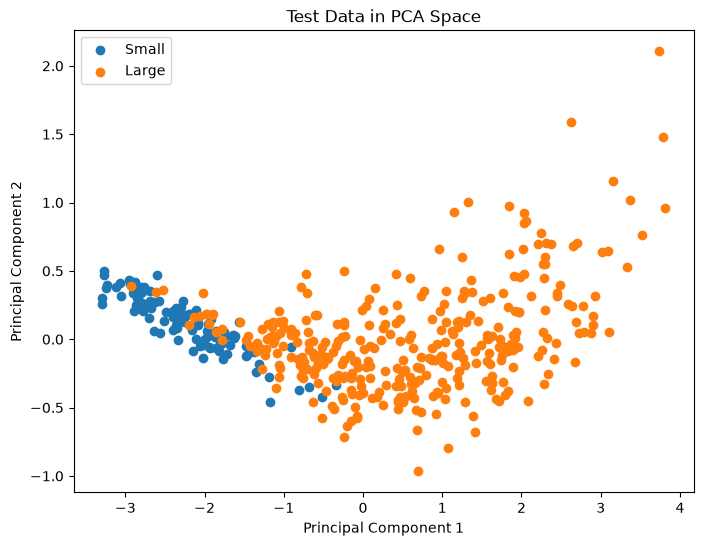

In [87]:
# Put your code here
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_svm)
X_test_pca = pca.transform(X_test_svm)
small_mask = y_test_label == "Small"
large_mask = y_test_label == "Large"

plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[small_mask, 0], X_test_pca[small_mask, 1], label="Small")
plt.scatter(X_test_pca[large_mask, 0], X_test_pca[large_mask, 1], label="Large")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Test Data in PCA Space")
plt.legend()
plt.show()

&#9989;  **Question 6.4 (3 points)**: Using only one of the principal components from the PCA performed above, how well can you classify helmet size using a simple threshold on that principal component?  In other words, find a threshold value for the first principal component that best separates the Small and Large helmet sizes in the training data (HINT: You can find this threshold manually or with one of the classification methods we've discussed in class). Then, evaluate the accuracy of this simple classifier on the testing sets.   How does this accuracy compare to the logistic regression, perceptron, and SVM models you trained in previous questions?


In [68]:
# Put your code here

&#9989;  **Question 6.5 (EXTRA CREDIT, 3 points)**: Repeat the scatter plot from question **6.3** showing Principal Component 1 on the x-axis and Principal Component 2 on the y-axis, but this time, add the decision boundary that you found from question **6.4** to the plot.  This should be a vertical line at the threshold value you found for Principal Component 1.  Label your axes and include a legend.


In [69]:
# Put your code here

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 6 complete", and push the changes to GitHub.



---
## Part 1. Continued

Now that you've finished your new "development" on your 202 turn-in repo, you can merge your work back into your `main` branch.

**&#9989; Do the following**:

7. Switch back to your `main` branch. 
8. Merge your `hw04_branch` with your `main` branch. 
9. Finally, push the changes to GitHub.

---
## Congratulations, you're done!

<img src="https://target.scene7.com/is/image/Target/GUEST_7dcf3394-4598-4bb8-886c-7f174b8f1a9b?wid=384&qlt=80" alt='Unicorn Helment @ Target.com' width=200px>

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework 4, and upload it there.

&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University